# 🧹 AutoPrep V1
### Automated Data Preprocessing Tool

---

## What is AutoPrep?
AutoPrep is a generic data preprocessing tool that accepts any structured
tabular CSV file and automatically cleans, encodes, scales, and generates
an analysis report — returning analysis-ready data.

---

## Supported Column Types
| Type | Description | Action |
|---|---|---|
| Numeric | Continuous int or float columns | Scale + Outlier Detection |
| Binary | Columns with exactly 2 values (0/1) | Keep as is |
| Ordinal | Sequential integer categories | OrdinalEncoder |
| Nominal | Low cardinality categorical columns | OneHotEncoder |
| ID | Unique identifier columns | Dropped automatically |
| Constant | Single unique value columns | Dropped automatically |


---

## V1 Constraints
- Accepts **structured tabular CSV files only**
- Single target column — optional
- No time series processing
- No NLP or free text processing
- No image or audio data
- No nested JSON columns
- Flat CSV structure only

---

## Pipeline

In [20]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler,RobustScaler,MinMaxScaler
from sklearn.preprocessing import OneHotEncoder,OrdinalEncoder,LabelEncoder
from sklearn.neighbors import LocalOutlierFactor

In [21]:

# LOADING THE DATASET

from google.colab import files
uploaded = files.upload()

df = pd.read_csv('tested.xls')

print("="*40)
print("DATASET LOADED SUCCESSFULLY")
print("="*40)
print(f"Rows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")
print("\nFirst 5 rows:")
df.head()


Saving tested.xls to tested (2).xls
DATASET LOADED SUCCESSFULLY
Rows: 418
Columns: 12

First 5 rows:


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [22]:
# AUTOPREP V1 CONSTRAINTS
print("="*40)
print("AUTOPREP V1")
print("="*40)
print("Supports: Numeric, Binary, Ordinal, Nominal columns")
print("Skips: Text, Date columns (coming in V2)")
print("Drops: ID, Constant columns automatically")
print("="*40)

AUTOPREP V1
Supports: Numeric, Binary, Ordinal, Nominal columns
Skips: Text, Date columns (coming in V2)
Drops: ID, Constant columns automatically


In [23]:
df1 = df.copy()



In [27]:
print("=" * 40)
print("COLUMN SCHEMA DETECTION")
print("=" * 40)

def detect_schema(df, cat_threshold=10):

    numeric_cols  = []
    binary_cols   = []
    ordinal_cols  = []
    nominal_cols  = []
    constant_cols = []
    unsupported_cols = []

    for col in df.columns:

        unique_count = df[col].nunique()
        dtype = df[col].dtype

        # Constant column
        if unique_count == 1:
            constant_cols.append(col)

       # High cardinality object = text or ID
        elif dtype == 'object' and unique_count > cat_threshold:
           unsupported_cols.append(col)

        # Object/category columns
        elif dtype == 'object' or dtype.name == 'category':
            nominal_cols.append(col)



        # Float columns
        elif dtype == 'float64':
            numeric_cols.append(col)

        # Integer columns
        elif dtype == 'int64':

            values = sorted(df[col].dropna().unique())

            if df[col].nunique() == len(df) or 'id' in col.lower():
              unsupported_cols.append(col)

            # Binary
            elif unique_count == 2 and set(values) == {0, 1}:
                binary_cols.append(col)

            # Ordinal
            elif values == list(range(min(values), min(values) + unique_count)) \
                 and unique_count <= cat_threshold:
                ordinal_cols.append(col)

            # Nominal
            elif unique_count <= cat_threshold:
                nominal_cols.append(col)

            # Numeric
            else:
                numeric_cols.append(col)

    return {
        "numeric": numeric_cols,
        "binary": binary_cols,
        "ordinal": ordinal_cols,
        "nominal": nominal_cols,
        "constant": constant_cols,
        "unsupported": unsupported_cols
    }


schema = detect_schema(df)

schema = detect_schema(df)

# Extract cols from schema for use in other cells
numeric_cols  = schema['numeric']
binary_cols   = schema['binary']
ordinal_cols  = schema['ordinal']
nominal_cols  = schema['nominal']

for dtype, cols in schema.items():

    if cols:
        print(f"\n{dtype.upper()} COLUMNS:")

        for col in cols:
            print(" →", col)

COLUMN SCHEMA DETECTION

NUMERIC COLUMNS:
 → Age
 → Fare

BINARY COLUMNS:
 → Survived

ORDINAL COLUMNS:
 → Pclass

NOMINAL COLUMNS:
 → Sex
 → SibSp
 → Parch
 → Embarked

UNSUPPORTED COLUMNS:
 → PassengerId
 → Name
 → Ticket
 → Cabin


## Data Quality Checks
AutoPrep V1 handles universally detectable quality issues only.
Domain specific validity checks (e.g. age ranges, medical thresholds)
are not in scope for V1.

In [25]:
print("=" * 40)
print("DATA QUALITY REPORT")
print("=" * 40)
print('\n')
print("-"*40)
print("Missing Values Count and Percentage:")
missing = df.isnull().sum()
missing_pct = ((missing * 100)/ (len(df))).round(2)
missing_report = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
})
print(missing_report[missing_report['Missing Count'] > 0])
print("\n")
print("-"*40)
print("Total Number of Duplicate rows:",df.duplicated().sum())
print("-"*40)
print("\n")
print("Basic Stats of the given Datset:")
print("\n")
print(df.describe())
print("-"*40)
print("\n")
print("DataTypes of all the columns:")
print(df.dtypes)
print("-"*40)

if schema['constant']:
    print("\nConstant Columns (will be dropped):")
    for col in schema['constant']:
        print(f" → {col}")

if schema['unsupported']:
    print("\nUnsupported Columns (will be skipped):")
    for col in schema['unsupported']:
        print(f" → {col}")

DATA QUALITY REPORT


----------------------------------------
Missing Values Count and Percentage:
       Missing Count  Missing %
Age               86      20.57
Fare               1       0.24
Cabin            327      78.23


----------------------------------------
Total Number of Duplicate rows: 0
----------------------------------------


Basic Stats of the given Datset:


       PassengerId    Survived      Pclass         Age       SibSp  \
count   418.000000  418.000000  418.000000  332.000000  418.000000   
mean   1100.500000    0.363636    2.265550   30.272590    0.447368   
std     120.810458    0.481622    0.841838   14.181209    0.896760   
min     892.000000    0.000000    1.000000    0.170000    0.000000   
25%     996.250000    0.000000    1.000000   21.000000    0.000000   
50%    1100.500000    0.000000    3.000000   27.000000    0.000000   
75%    1204.750000    1.000000    3.000000   39.000000    1.000000   
max    1309.000000    1.000000    3.000000   76.000000   

In [30]:
# CELL 5 — HANDLE MISSING VALUES
print("="*40)
print("HANDLING MISSING VALUES")
print("="*40)

MISSING_THRESHOLD = 40
df_clean = df.copy()

for col in df_clean.columns:

    if missing_pct[col] == 0:
        continue

    if missing_pct[col] > MISSING_THRESHOLD:
        df_clean.drop(columns=col, inplace=True)
        print(f"Dropped {col} — {missing_pct[col]}% missing")
        continue

    if col in numeric_cols:
        if df_clean[col].skew() > 1:
            df_clean[col] = df_clean[col].fillna(df_clean[col].median())
            print(f"{col} → filled with median")
        else:
            df_clean[col] = df_clean[col].fillna(df_clean[col].mean())
            print(f"{col} → filled with mean")

    elif col in nominal_cols or col in ordinal_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
        print(f"{col} → filled with mode")

    elif col in binary_cols:
        df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])
        print(f"{col} → filled with mode")

print(f"\nMissing values remaining: {df_clean.isnull().sum().sum()}")





HANDLING MISSING VALUES
Age → filled with mean
Fare → filled with median
Dropped Cabin — 78.23% missing

Missing values remaining: 0
0      False
1      False
2      False
3      False
4      False
       ...  
413    False
414    False
415    False
416    False
417    False
Length: 418, dtype: bool


In [31]:
# CELL 6 — REMOVE DUPLICATES
print("="*40)
print("REMOVING DUPLICATES")
print("="*40)

before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)

print(f"Rows before: {before}")
print(f"Rows after: {after}")
print(f"Duplicates removed: {before - after}")

REMOVING DUPLICATES
Rows before: 418
Rows after: 418
Duplicates removed: 0


OUTLIER DETECTION

VISUALIZATION BEFORE OUTLIER REMOVAL



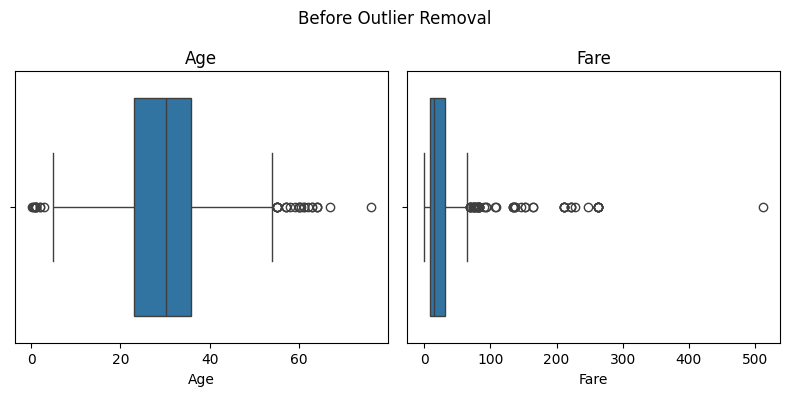

Outliers detected: 21
Normal points: 397
Rows removed: 21

VISUALIZATION AFTER OUTLIER REMOVAL



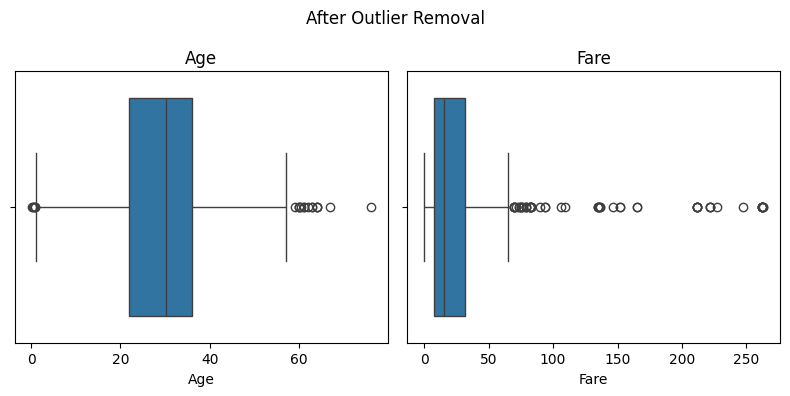

In [34]:
# CELL 7 - HANDLING OUTLIERS
print("="*40)
print("OUTLIER DETECTION")
print("="*40)

# Visualize before
print("\nVISUALIZATION BEFORE OUTLIER REMOVAL\n")
fig, axes = plt.subplots(1, len(numeric_cols),
                         figsize=(4*len(numeric_cols), 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df_clean[col], ax=axes[i])
    axes[i].set_title(col)
plt.suptitle('Before Outlier Removal')
plt.tight_layout()
plt.savefig('outliers_before.png')
plt.show()
plt.close()

# Apply LOF
from sklearn.neighbors import LocalOutlierFactor

lof = LocalOutlierFactor(n_neighbors=20, contamination=0.05)
pred = lof.fit_predict(df_clean[numeric_cols])

outliers = (pred == -1)
print(f"Outliers detected: {outliers.sum()}")
print(f"Normal points: {(pred == 1).sum()}")

# Remove outliers
before = len(df_clean)
df_clean = df_clean[~outliers].reset_index(drop=True)
after = len(df_clean)
print(f"Rows removed: {before - after}")

# Visualize after
print("\nVISUALIZATION AFTER OUTLIER REMOVAL\n")
fig, axes = plt.subplots(1, len(numeric_cols),
                         figsize=(4*len(numeric_cols), 4))
for i, col in enumerate(numeric_cols):
    sns.boxplot(x=df_clean[col], ax=axes[i])
    axes[i].set_title(col)
plt.suptitle('After Outlier Removal')
plt.tight_layout()
plt.savefig('outliers_after.png')
plt.show()
plt.close()